In [1]:
import pdfplumber
import pandas as pd
import re
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data_with_wa_scores.csv')

In [4]:
print("Daten geladen! Anzahl Zeilen:", len(df))

Daten geladen! Anzahl Zeilen: 211559


In [5]:
print(df.head(10))

   jahr geschlecht altersklasse disziplin leistung  wind                name  \
0  2017          W       Frauen     100 m    10.95  +1,3  Gina Lueckenkemper   
1  2017          W       Frauen     100 m    11.06  +1,8       Rebekka Haase   
2  2017          W       Frauen     100 m    11.14  -0,2          Lisa Mayer   
3  2017          W       Frauen     100 m    11.24  +0,3       Tatjana Pinto   
4  2017          W       Frauen     100 m    11.25  +1,9          Sina Mayer   
5  2017          W       Frauen     100 m    11.29  +1,9     Jennifer Montag   
6  2017          W       Frauen     100 m    11.29  +1,9        Lara Matheis   
7  2017          W       Frauen     100 m    11.33  +1,7       Keshia Kwadwo   
8  2017          W       Frauen     100 m    11.36  +0,4       Laura Mueller   
9  2017          W       Frauen     100 m    11.41  +1,8        Lisa Nippgen   

   geburtsjahr                   verein   datum          ort  wa_score  
0         1996      LG Olympia Dortmund  05.08

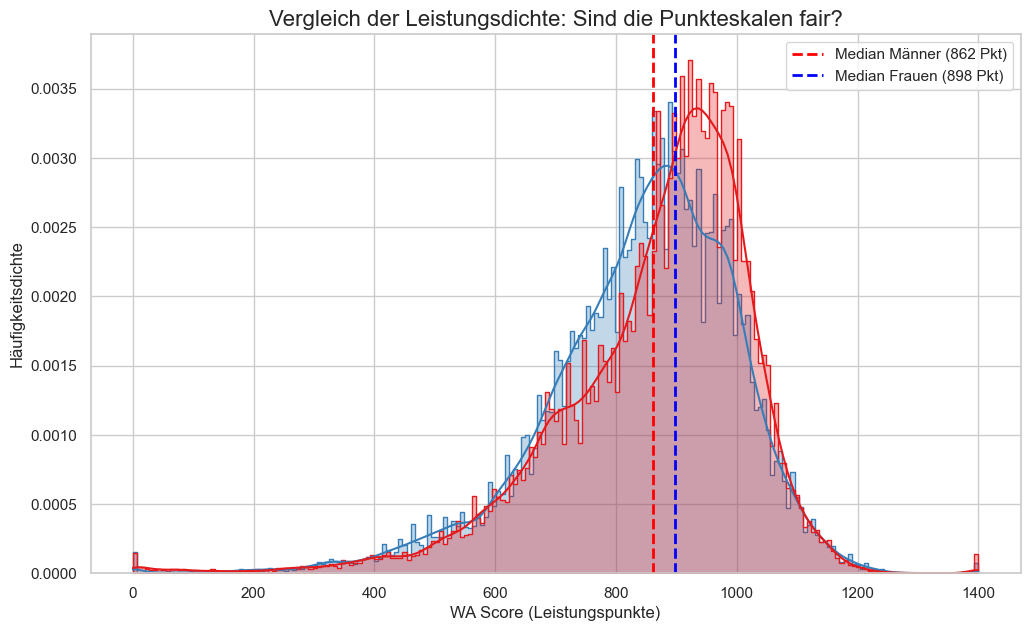

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv('data_with_wa_scores.csv')

# 2. Daten bereinigen
# Wir stellen sicher, dass der Score wirklich eine Zahl ist (Fehler werden zu NaN)
df['wa_score'] = pd.to_numeric(df['wa_score'], errors='coerce')
# Wir werfen leere Zeilen raus, damit der Plot nicht crasht
df = df.dropna(subset=['wa_score'])

# 3. Den Plot vorbereiten
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid") # Hübsches Raster im Hintergrund

# 4. Das Histogramm zeichnen (Der "Berg")
# 'kde=True' macht die glatte Linie über die Balken
# 'stat="density"' normiert die Daten, damit man sie vergleichen kann, 
# auch wenn es z.B. viel mehr Männer als Frauen im Datensatz gäbe.
sns.histplot(
    data=df, 
    x='wa_score', 
    hue='geschlecht',       # Unterscheidung nach Farbe
    element="step",         # Darstellungsart
    stat="density",         # Wichtig für den fairen Vergleich!
    common_norm=False,      # Jedes Geschlecht wird für sich berechnet
    kde=True,               # Die weiche Kurve aktivieren
    palette='Set1',         # Farben (Rot/Blau meistens)
    alpha=0.3               # Transparenz der Flächen
)

# 5. Mediane berechnen (Die "Mitte" der Leistung)
median_m = df[df['geschlecht'] == 'M']['wa_score'].median()
median_w = df[df['geschlecht'] == 'W']['wa_score'].median()

# 6. Linien für den Median einzeichnen
plt.axvline(median_m, color='red', linestyle='--', linewidth=2, label=f'Median Männer ({median_m:.0f} Pkt)')
plt.axvline(median_w, color='blue', linestyle='--', linewidth=2, label=f'Median Frauen ({median_w:.0f} Pkt)')

# 7. Beschriftung
plt.title('Vergleich der Leistungsdichte: Sind die Punkteskalen fair?', fontsize=16)
plt.xlabel('WA Score (Leistungspunkte)', fontsize=12)
plt.ylabel('Häufigkeitsdichte', fontsize=12)
plt.legend() # Legende anzeigen

# 8. Anzeigen
plt.show()

In [10]:
import matplotlib
import os

# 1. Korrekter Befehl um das Cache-Verzeichnis zu finden
cache_dir = matplotlib.get_cachedir()
print(f"Cache-Verzeichnis gefunden: {cache_dir}")

# 2. Den Cache löschen (json Dateien entfernen)
found = False
# Prüfen, ob das Verzeichnis überhaupt existiert
if os.path.exists(cache_dir):
    for filename in os.listdir(cache_dir):
        # Wir suchen nach Dateien wie 'fontlist-v330.json'
        if filename.startswith('fontlist') and filename.endswith('.json'):
            file_path = os.path.join(cache_dir, filename)
            try:
                os.remove(file_path)
                print(f"Gelöscht: {filename}")
                found = True
            except OSError as e:
                print(f"Fehler beim Löschen von {filename}: {e}")
else:
    print("Cache-Verzeichnis existiert nicht (das ist auch okay).")

if found:
    print("Erfolg! Der Font-Cache wurde gelöscht.")
    print("BITTE JETZT: Starte deinen Kernel / dein Programm komplett neu.")
else:
    print("Keine Font-Cache-Datei gefunden (vielleicht war sie schon weg).")

Cache-Verzeichnis gefunden: /Users/snigglypoof/.matplotlib
Gelöscht: fontlist-v390.json
Erfolg! Der Font-Cache wurde gelöscht.
BITTE JETZT: Starte deinen Kernel / dein Programm komplett neu.


In [2]:
import matplotlib.font_manager

# Suche nach allen Schriften, die "Public" im Namen haben
fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist if 'Public' in f.name]

if len(fonts) > 0:
    print("Gefunden! Die genauen Namen sind:", set(fonts))
else:
    print("Nichts gefunden. Python sieht die Schriftart nicht.")

Gefunden! Die genauen Namen sind: {'Publico Text', 'Public Sans'}


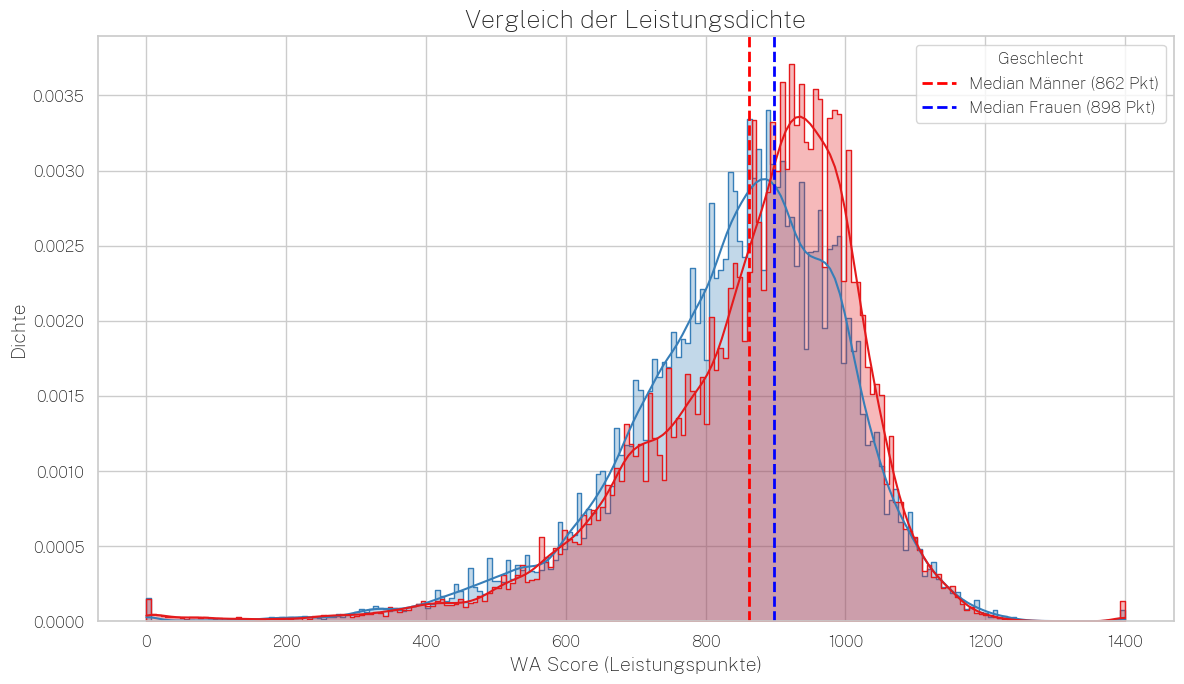

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager

# ---------------------------------------------------------
# HIER DEN GENAUEN NAMEN EINTRAGEN (aus Schritt 1)
# ---------------------------------------------------------
meine_schrift = 'Public Sans'  
# Falls Schritt 1 leer war, probiere 'Arial' oder installiere die Font neu.

# Daten laden
df = pd.read_csv('data_with_wa_scores.csv')
df['wa_score'] = pd.to_numeric(df['wa_score'], errors='coerce')
df = df.dropna(subset=['wa_score'])

# Design setzen
sns.set_theme(style="whitegrid")

# SCHRIFTART ERZWINGEN
# Wir überschreiben die Font-Familie direkt in den Parametern
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [meine_schrift, 'Arial', 'DejaVu Sans']

# Plot erstellen
plt.figure(figsize=(12, 7))

# Histogramm
sns.histplot(
    data=df, 
    x='wa_score', 
    hue='geschlecht', 
    element="step", 
    stat="density", 
    common_norm=False, 
    kde=True, 
    palette='Set1', 
    alpha=0.3
)

# 5. Mediane berechnen (Die "Mitte" der Leistung)
median_m = df[df['geschlecht'] == 'M']['wa_score'].median()
median_w = df[df['geschlecht'] == 'W']['wa_score'].median()

# 6. Linien für den Median einzeichnen
plt.axvline(median_m, color='red', linestyle='--', linewidth=2, label=f'Median Männer ({median_m:.0f} Pkt)')
plt.axvline(median_w, color='blue', linestyle='--', linewidth=2, label=f'Median Frauen ({median_w:.0f} Pkt)')

# Titel und Achsen mit expliziter Font-Angabe (doppelt hält besser)
plt.title('Vergleich der Leistungsdichte', fontname=meine_schrift, fontsize=18, fontweight='bold')
plt.xlabel('WA Score (Leistungspunkte)', fontname=meine_schrift, fontsize=14)
plt.ylabel('Dichte', fontname=meine_schrift, fontsize=14)

# Auch die Achsen-Zahlen ändern
plt.xticks(fontname=meine_schrift, fontsize=12)
plt.yticks(fontname=meine_schrift, fontsize=12)
plt.legend(title='Geschlecht', fontsize=12)

# Speichern & Anzeigen
plt.tight_layout()
plt.show()

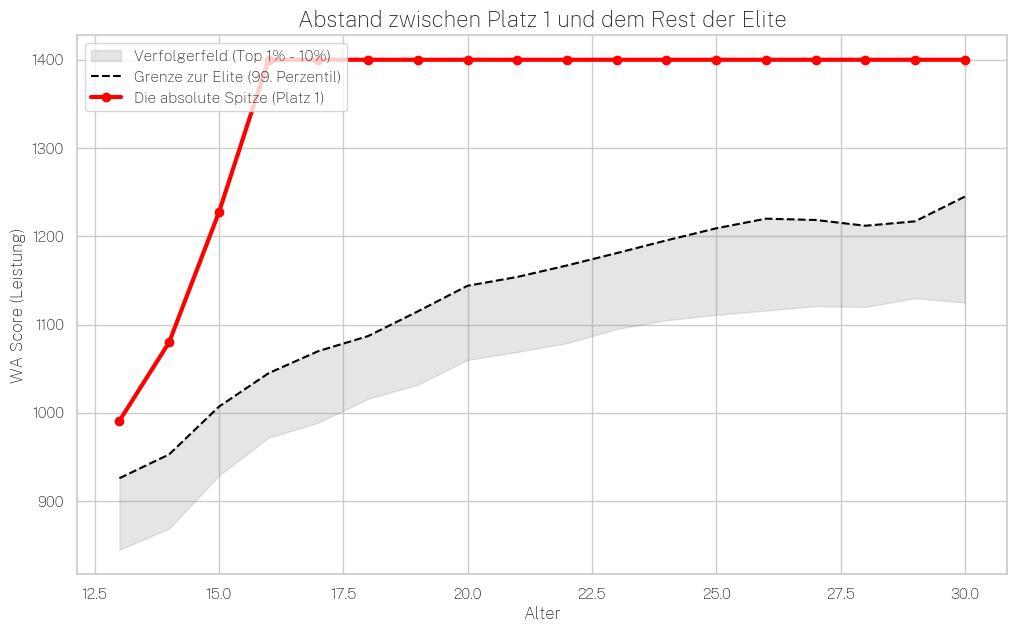

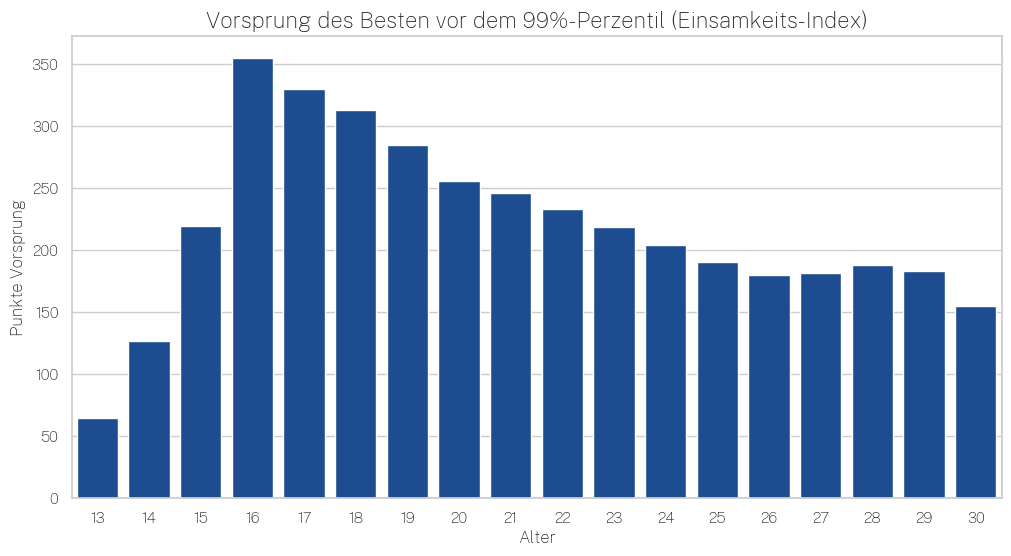

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Daten laden & vorbereiten
df = pd.read_csv('data_with_wa_scores.csv')
df['wa_score'] = pd.to_numeric(df['wa_score'], errors='coerce')
df['alter'] = df['jahr'] - df['geburtsjahr']

# Filtern: Nur sinnvolle Alter (13 bis 30) und vorhandene Scores
df = df.dropna(subset=['wa_score'])
df = df[(df['alter'] >= 13) & (df['alter'] <= 30)]

# 2. Statistiken pro Alter berechnen
# Wir wollen wissen: Was ist das Maximum? Wo fängt die Top-Gruppe an (99% Perzentil)?
age_stats = df.groupby('alter')['wa_score'].agg(
    max_score='max',                    # Der Allerbeste
    p99=lambda x: np.percentile(x, 99), # Die Top 1% Grenze
    p90=lambda x: np.percentile(x, 90), # Die Top 10% Grenze
    median='median'                     # Der Durchschnitt
).reset_index()

# Berechne den "Abstand" (Gap): Wie viel besser ist der Erste als der "Rest der Elite"?
age_stats['gap'] = age_stats['max_score'] - age_stats['p99']

# Design
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Public Sans', 'Arial']

# --- PLOT A: Die "Schere" (Visueller Verlauf) ---
plt.figure(figsize=(12, 7))

# Bereich der "Verfolger" (Top 10% bis Top 1%) grau schattieren
plt.fill_between(age_stats['alter'], age_stats['p90'], age_stats['p99'], 
                 color='gray', alpha=0.2, label='Verfolgerfeld (Top 1% - 10%)')

# Die Linien
plt.plot(age_stats['alter'], age_stats['p99'], color='black', linestyle='--', label='Grenze zur Elite (99. Perzentil)')
plt.plot(age_stats['alter'], age_stats['max_score'], color='red', linewidth=3, marker='o', label='Die absolute Spitze (Platz 1)')

plt.title('Abstand zwischen Platz 1 und dem Rest der Elite', fontsize=16)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('WA Score (Leistung)', fontsize=12)
plt.legend(loc='upper left')
plt.show()

# --- PLOT B: Der "Einsamkeits-Index" (Balkendiagramm) ---
plt.figure(figsize=(12, 6))

# Wir zeigen nur die Differenz: Je höher der Balken, desto "einsamer" ist der Sieger
sns.barplot(data=age_stats, x='alter', y='gap', color="#0a4aa3") # Dunkelrot

plt.title('Vorsprung des Besten vor dem 99%-Perzentil (Einsamkeits-Index)', fontsize=16)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Punkte Vorsprung', fontsize=12)

plt.show()

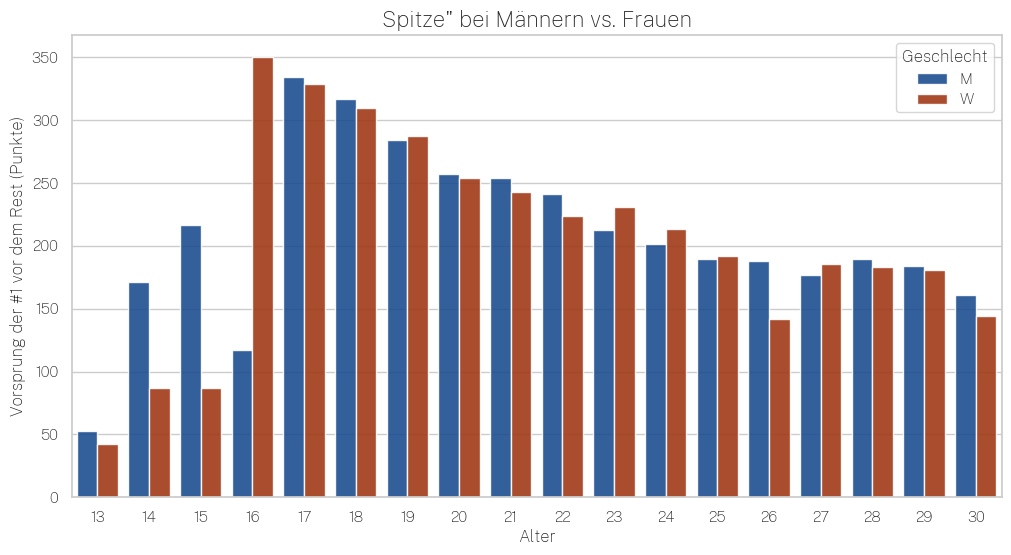

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Daten laden
df = pd.read_csv('data_with_wa_scores.csv')
df['wa_score'] = pd.to_numeric(df['wa_score'], errors='coerce')
df['alter'] = df['jahr'] - df['geburtsjahr']

# Filtern (Alter 13-30)
df = df.dropna(subset=['wa_score'])
df = df[(df['alter'] >= 13) & (df['alter'] <= 30)]

# 2. Berechnung getrennt nach Geschlecht
age_gender_stats = df.groupby(['alter', 'geschlecht'])['wa_score'].agg(
    max_score='max',
    p99=lambda x: np.percentile(x, 99)
).reset_index()

# Den Vorsprung (Gap) berechnen
age_gender_stats['gap'] = age_gender_stats['max_score'] - age_gender_stats['p99']

# 3. Plotten
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
# Falls du Public Sans hast, sonst Arial
plt.rcParams['font.sans-serif'] = ['Public Sans', 'Arial'] 

plt.figure(figsize=(12, 6))
# 'hue' sorgt für die farbliche Trennung
sns.barplot(data=age_gender_stats, x='alter', y='gap', hue='geschlecht', 
            palette={'M': '#0a4aa3', 'W': "#b82e00"}, alpha=0.9)

plt.title('Spitze" bei Männern vs. Frauen', fontsize=16)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Vorsprung der #1 vor dem Rest (Punkte)', fontsize=12)
plt.legend(title='Geschlecht')

plt.show()

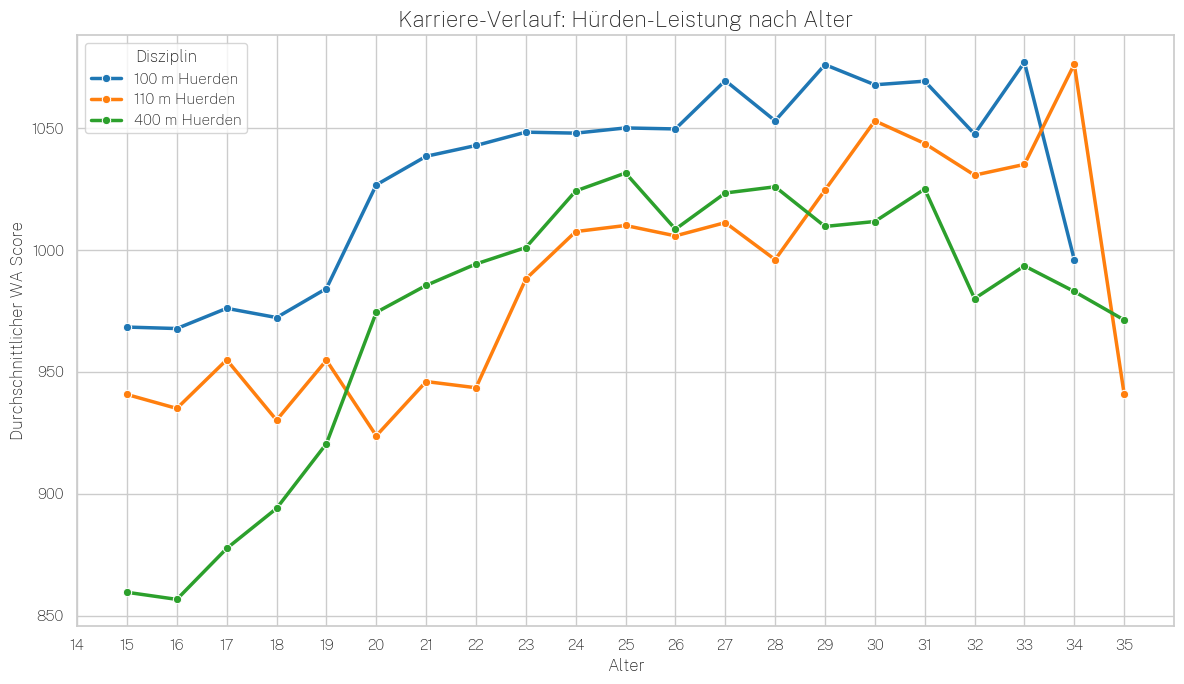

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv('data_with_wa_scores.csv')
df['wa_score'] = pd.to_numeric(df['wa_score'], errors='coerce')
df['alter'] = df['jahr'] - df['geburtsjahr']

# 2. Filtern: Nur Hürden & Alter 14-35
df_huerden = df[
    (df['alter'] >= 14) & 
    (df['alter'] <= 35) & 
    (df['disziplin'].str.contains('uerden', case=False))
].dropna(subset=['wa_score'])

# 3. Aggregieren (Mittelwert pro Alter)
trend = df_huerden.groupby(['alter', 'disziplin'])['wa_score'].mean().reset_index()

# 4. Plotten
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Public Sans', 'Arial']

plt.figure(figsize=(12, 7))
sns.lineplot(data=trend, x='alter', y='wa_score', hue='disziplin', 
             marker='o', linewidth=2.5, palette="tab10")

plt.title('Karriere-Verlauf: Hürden-Leistung nach Alter', fontsize=16)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Durchschnittlicher WA Score', fontsize=12)
plt.xticks(range(14, 36)) # Jedes Jahr anzeigen
plt.legend(title='Disziplin')

plt.tight_layout()
plt.show()

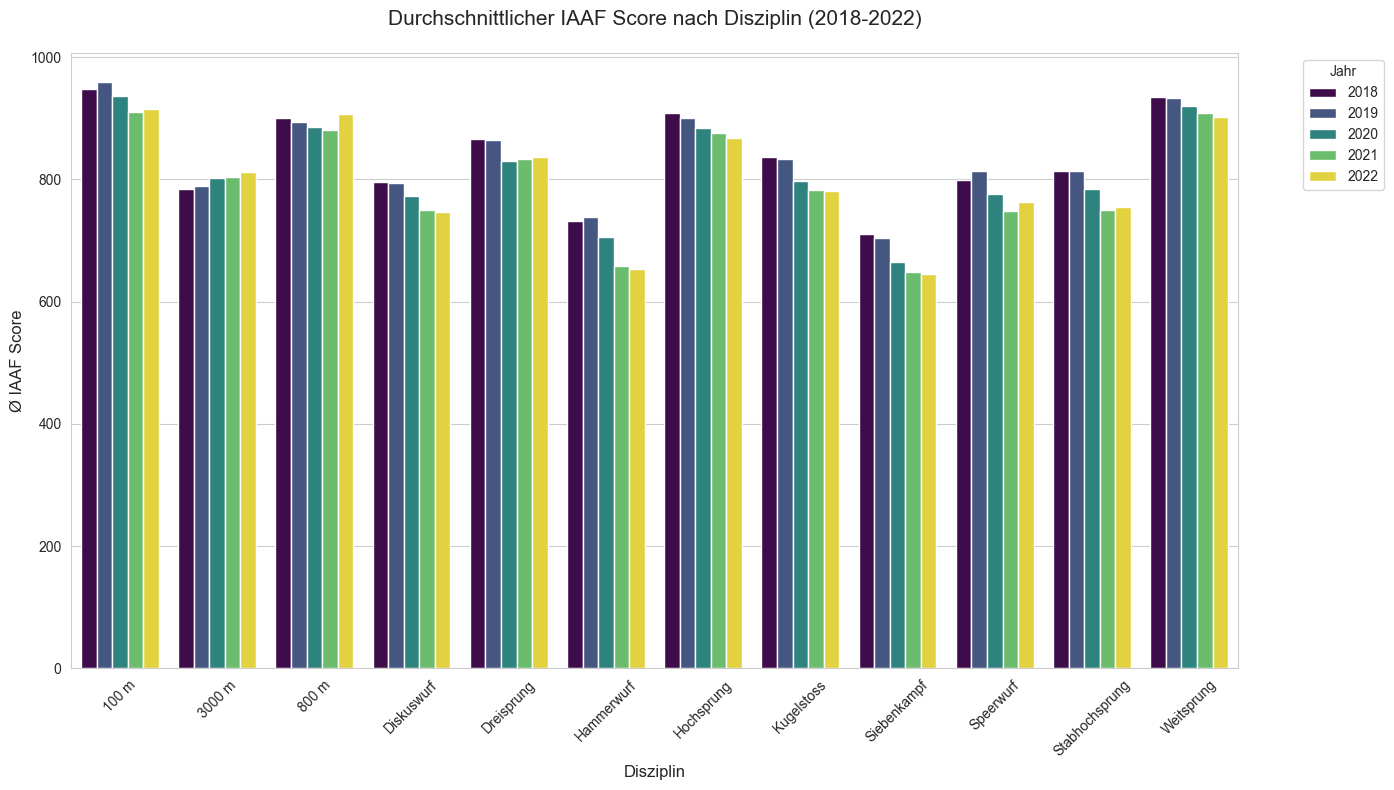

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv('Data.csv', delimiter=';')

# 2. Datenbereinigung
# Wir entfernen Scores über 2000, da dies in diesem Datensatz oft Tippfehler sind
df_clean = df[df['iaaf_score'] < 2000].copy()

# Zeitraum auf die Jahre um Corona einschränken
years_to_compare = [2018, 2019, 2020, 2021, 2022]
df_subset = df_clean[df_clean['jahr'].isin(years_to_compare)]

# 3. Top-Disziplinen auswählen (um die Grafik lesbar zu halten)
# Wir nehmen die 12 Disziplinen mit den meisten Einträgen
top_disciplines = df_subset['disziplin'].value_counts().nlargest(12).index.tolist()
df_plot = df_subset[df_subset['disziplin'].isin(top_disciplines)]

# 4. Durchschnittswerte berechnen
# Wir gruppieren nach Disziplin und Jahr
performance_comparison = df_plot.groupby(['disziplin', 'jahr'])['iaaf_score'].mean().reset_index()

# 5. Visualisierung
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Gruppierter Barplot
sns.barplot(
    data=performance_comparison, 
    x='disziplin', 
    y='iaaf_score', 
    hue='jahr', 
    palette='viridis'
)

# Layout-Optimierung
plt.title('Durchschnittlicher IAAF Score nach Disziplin (2018-2022)', fontsize=15, pad=20)
plt.ylabel('Ø IAAF Score', fontsize=12)
plt.xlabel('Disziplin', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Jahr', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

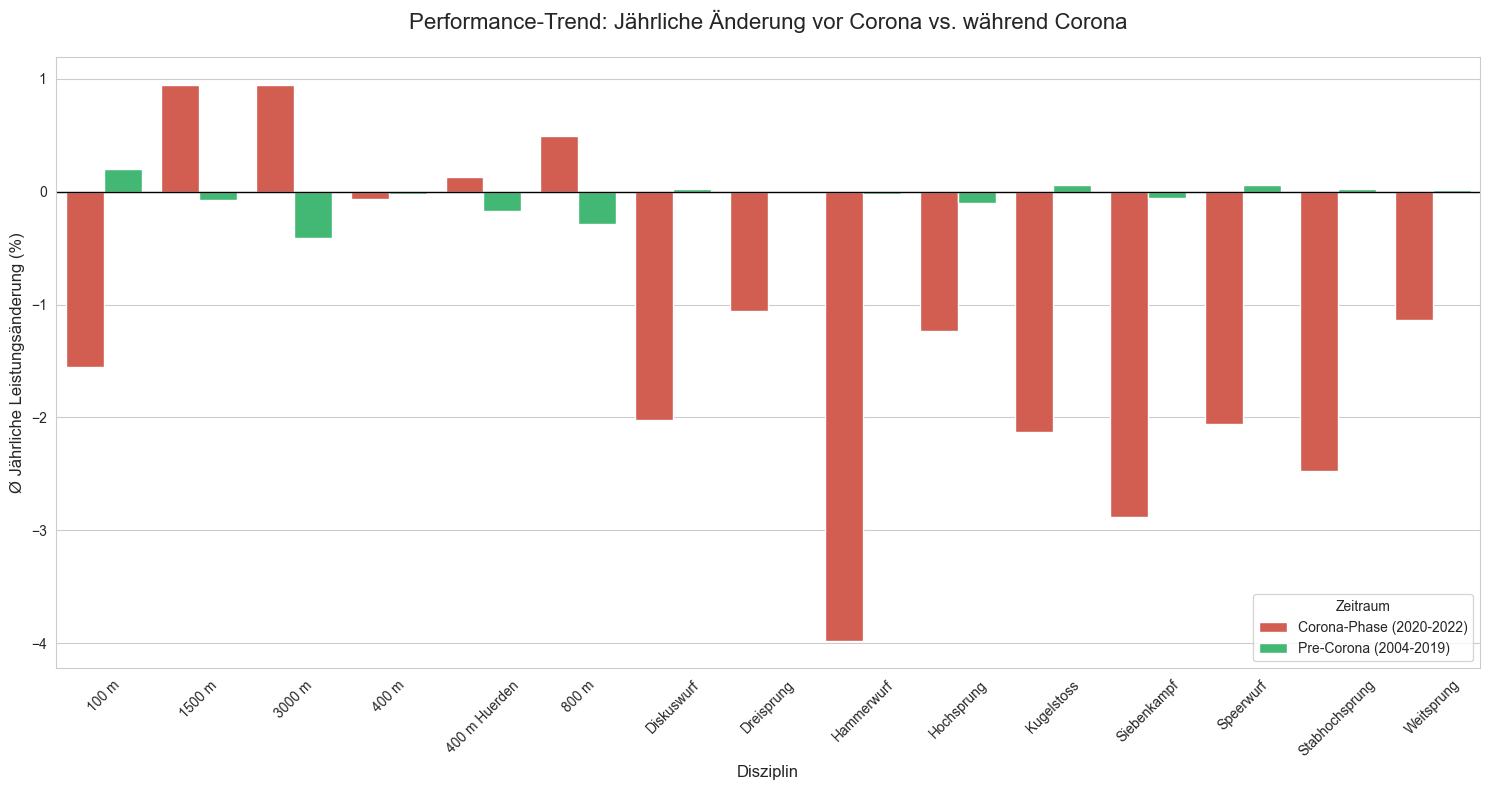

Vergleich der durchschnittlichen jährlichen Wachstumsraten (%):
periode         Corona-Phase (2020-2022)  Pre-Corona (2004-2019)
disziplin                                                       
100 m                          -1.554178                0.205376
1500 m                          0.948023               -0.075333
3000 m                          0.942235               -0.406895
400 m                          -0.063339               -0.020994
400 m Huerden                   0.134552               -0.175076
800 m                           0.491579               -0.290357
Diskuswurf                     -2.022229                0.020385
Dreisprung                     -1.055323               -0.004363
Hammerwurf                     -3.976935               -0.019224
Hochsprung                     -1.234613               -0.096281
Kugelstoss                     -2.130428                0.060813
Siebenkampf                    -2.879378               -0.058170
Speerwurf                 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden und Grundbereinigung
df = pd.read_csv('Data.csv', delimiter=';')
df_clean = df[df['iaaf_score'] < 2000].copy() # Ausreißer entfernen

# Wir betrachten Daten ab 2003, um die Änderung für 2004 berechnen zu können
df_clean = df_clean[df_clean['jahr'] >= 2003]

# Top 15 Disziplinen für eine saubere Grafik
top_disciplines = df_clean['disziplin'].value_counts().nlargest(15).index.tolist()
df_top = df_clean[df_clean['disziplin'].isin(top_disciplines)]

# 2. Durchschnittlichen Score pro Disziplin und Jahr berechnen
annual_scores = df_top.groupby(['disziplin', 'jahr'])['iaaf_score'].mean().reset_index()

# 3. Jährliche prozentuale Änderung berechnen (YoY Growth)
annual_scores = annual_scores.sort_values(['disziplin', 'jahr'])
annual_scores['pct_change'] = annual_scores.groupby('disziplin')['iaaf_score'].pct_change() * 100

# 4. Perioden definieren: Langzeit-Schnitt vs. Corona-Phase
def categorize_period(year):
    if 2004 <= year <= 2019:
        return 'Pre-Corona (2004-2019)'
    elif 2020 <= year <= 2022:
        return 'Corona-Phase (2020-2022)'
    return None

annual_scores['periode'] = annual_scores['jahr'].apply(categorize_period)

# 5. Durchschnitt der Änderungen innerhalb der Perioden berechnen
comparison = annual_scores.dropna(subset=['periode', 'pct_change'])
comparison = comparison.groupby(['disziplin', 'periode'])['pct_change'].mean().reset_index()

# 6. Visualisierung
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Balkendiagramm: Grün für stabilen Trend, Rot für die Corona-Phase
sns.barplot(
    data=comparison,
    x='disziplin',
    y='pct_change',
    hue='periode',
    palette=['#e74c3c', '#2ecc71'] # Rot für Corona, Grün für Pre-Corona
)

# Formatierung
plt.title('Performance-Trend: Jährliche Änderung vor Corona vs. während Corona', fontsize=16, pad=20)
plt.ylabel('Ø Jährliche Leistungsänderung (%)', fontsize=12)
plt.xlabel('Disziplin', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1) # Null-Linie zur Orientierung
plt.legend(title='Zeitraum', loc='lower right')

plt.tight_layout()
plt.show()

# Tabellarische Zusammenfassung für den Bericht
print("Vergleich der durchschnittlichen jährlichen Wachstumsraten (%):")
print(comparison.pivot(index='disziplin', columns='periode', values='pct_change'))

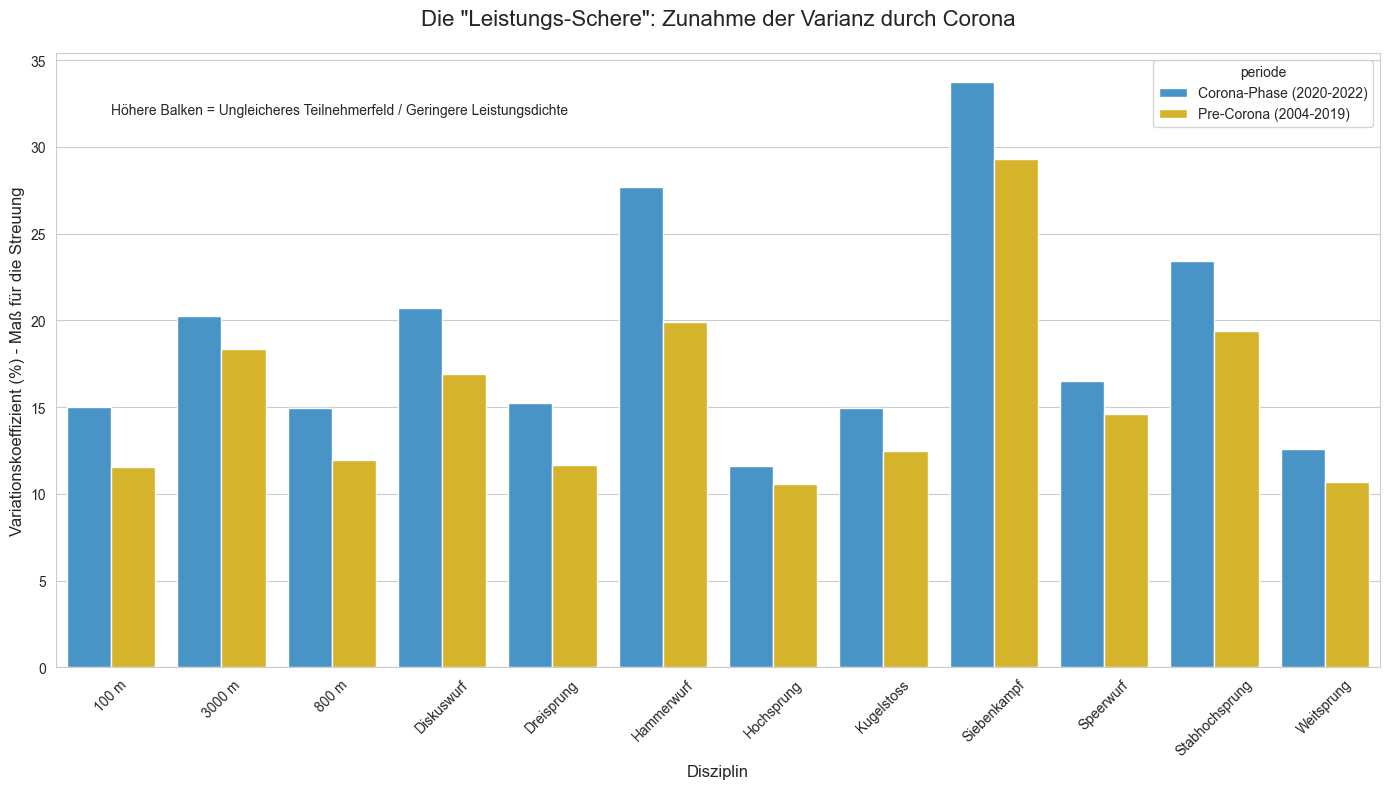

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden und Ausreißer entfernen
df = pd.read_csv('Data.csv', delimiter=';')
df_clean = df[df['iaaf_score'] < 2000].copy()

# Zeitraum eingrenzen
df_clean = df_clean[df_clean['jahr'] >= 2004]

# Top 12 Disziplinen für die Übersicht
top_disciplines = df_clean['disziplin'].value_counts().nlargest(12).index.tolist()
df_top = df_clean[df_clean['disziplin'].isin(top_disciplines)]

# 2. Statistiken berechnen: Mittelwert und Standardabweichung pro Jahr
stats = df_top.groupby(['disziplin', 'jahr'])['iaaf_score'].agg(['mean', 'std']).reset_index()

# 3. Variationskoeffizient (CV) berechnen
# Er gibt an, wie viel Prozent die Leistungen um den Mittelwert streuen.
stats['cv'] = (stats['std'] / stats['mean']) * 100

# 4. Zeitperioden definieren
def categorize_period(year):
    if 2004 <= year <= 2019:
        return 'Pre-Corona (2004-2019)'
    elif 2020 <= year <= 2022:
        return 'Corona-Phase (2020-2022)'
    return None

stats['periode'] = stats['jahr'].apply(categorize_period)

# 5. Durchschnittliche Varianz pro Periode
cv_comparison = stats.dropna(subset=['periode']).groupby(['disziplin', 'periode'])['cv'].mean().reset_index()

# 6. Visualisierung
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Barplot: Blau (Normal) vs. Gold (Corona)
sns.barplot(
    data=cv_comparison,
    x='disziplin',
    y='cv',
    hue='periode',
    palette=['#3498db', '#f1c40f']
)

plt.title('Die "Leistungs-Schere": Zunahme der Varianz durch Corona', fontsize=16, pad=20)
plt.ylabel('Variationskoeffizient (%) - Maß für die Streuung', fontsize=12)
plt.xlabel('Disziplin', fontsize=12)
plt.xticks(rotation=45)

# Erklärungstext in die Grafik einfügen
plt.text(0, plt.ylim()[1]*0.9, "Höhere Balken = Ungleicheres Teilnehmerfeld / Geringere Leistungsdichte", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

# 1. Datensatz laden
# Wir nutzen sep=';', da deine Datei Semikolons als Trenner verwendet
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# 2. Die ersten 5 Zeilen anzeigen
print("--- Vorschau der Daten ---")
print(df.head())

# 3. Struktur der Daten prüfen (Spaltentypen, fehlende Werte)
print("\n--- Informationen zum Datensatz ---")
print(df.info())

# 4. Statistische Kurzübersicht der Scores
print("\n--- Deskriptive Statistik der IAAF Scores ---")
print(df['iaaf_score'].describe())

--- Vorschau der Daten ---
   jahr geschlecht altersklasse disziplin leistung  wind                name  \
0  2017          W       Frauen     100 m    10,95  +1,3  Gina Lueckenkemper   
1  2017          W       Frauen     100 m    11,06  +1,8       Rebekka Haase   
2  2017          W       Frauen     100 m    11,14  -0,2          Lisa Mayer   
3  2017          W       Frauen     100 m    11,24  +0,3       Tatjana Pinto   
4  2017          W       Frauen     100 m    11,25  +1,9          Sina Mayer   

   geburtsjahr               verein   datum          ort  iaaf_score  
0         1996  LG Olympia Dortmund  05.08.   London/GBR        1211  
1         1993     LV 90 Erzgebirge  25.05.   Zeulenroda        1187  
2         1996   Sprintteam Wetzlar  27.08.       Berlin        1169  
3         1992         LC Paderborn  15.07.   Ninove/BEL        1148  
4         1995     LAZ Zweibruecken  11.06.   Regensburg        1146  

--- Informationen zum Datensatz ---
<class 'pandas.core.frame.Dat

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1311/2579059649.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elite_counts, x='jahr', y='anzahl', palette='viridis')


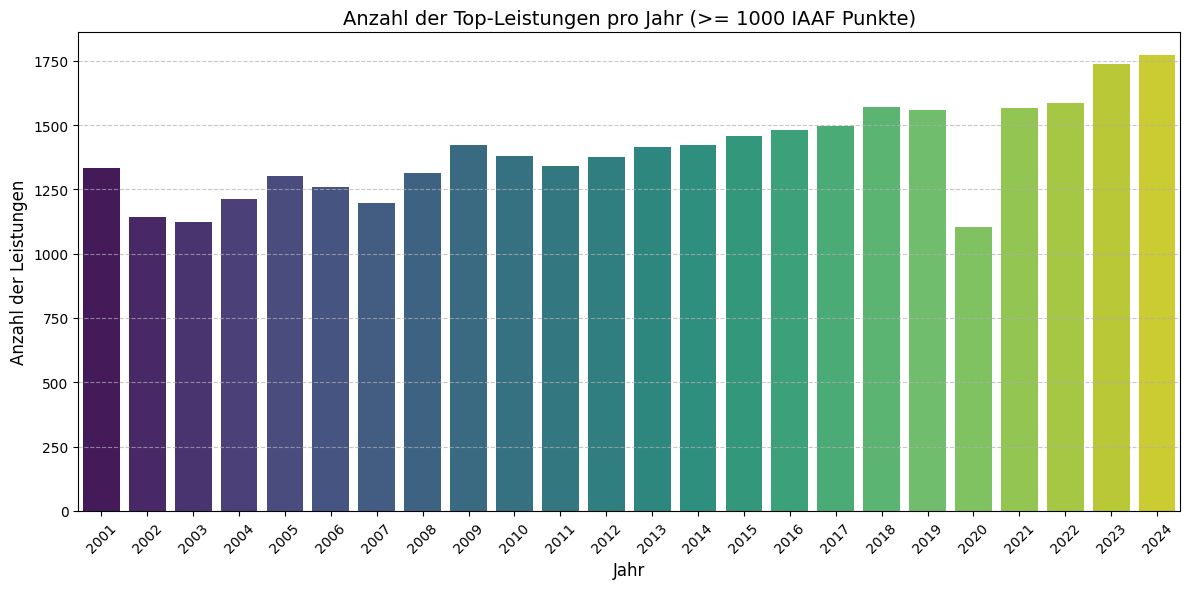

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Datensatz laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# 2. Daten filtern: Nur Leistungen mit >= 1000 Punkten
# (Hinweis: Wir betrachten hier alle Jahre im Datensatz)
elite_df = df[df['iaaf_score'] >= 1000]

# 3. Anzahl pro Jahr zählen
# Wir gruppieren nach dem Jahr und zählen die Einträge
elite_counts = elite_df.groupby('jahr').size().reset_index(name='anzahl')

# 4. Diagramm erstellen
plt.figure(figsize=(12, 6))
sns.barplot(data=elite_counts, x='jahr', y='anzahl', palette='viridis')

# Optische Anpassungen
plt.title('Anzahl der Top-Leistungen pro Jahr (>= 1000 IAAF Punkte)', fontsize=14)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl der Leistungen', fontsize=12)
plt.xticks(rotation=45)  # Jahre leicht schräg stellen für bessere Lesbarkeit
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Diagramm anzeigen
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy import stats

# Daten laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# Gruppen definieren
group_pre = df[df['jahr'] < 2020]['iaaf_score']
group_2020 = df[df['jahr'] == 2020]['iaaf_score']

# Welch-t-Test durchführen (da die Gruppengrößen sehr unterschiedlich sind)
t_stat, p_value = stats.ttest_ind(group_pre, group_2020, equal_var=False)

print(f"Mittelwert Vor-Corona: {group_pre.mean():.2f}")
print(f"Mittelwert 2020: {group_2020.mean():.2f}")
print(f"P-Wert: {p_value}")

if p_value < 0.05:
    print("Das Ergebnis ist statistisch signifikant.")
else:
    print("Es konnte kein signifikanter Unterschied festgestellt werden.")

Mittelwert Vor-Corona: 852.97
Mittelwert 2020: 819.75
P-Wert: 1.5194972502885084e-65
Das Ergebnis ist statistisch signifikant.


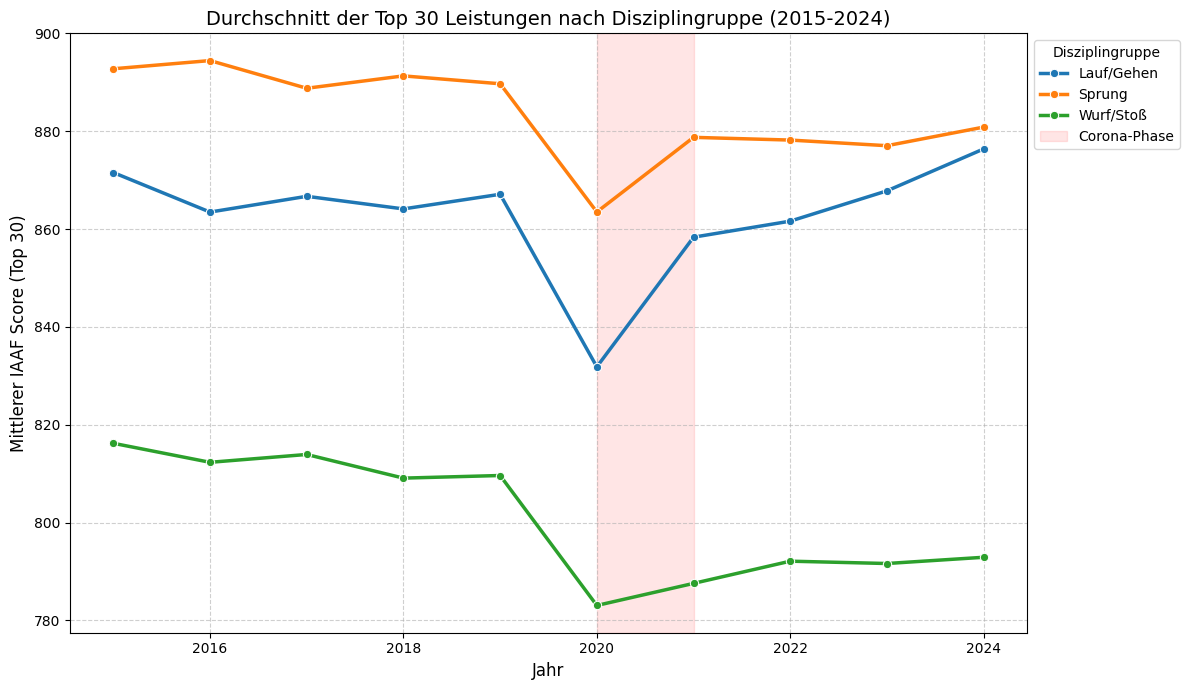

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# 2. Disziplinen in Gruppen kategorisieren
def categorize_discipline(d):
    d = str(d).lower()
    if any(x in d for x in ['sprung']):
        return 'Sprung'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']):
        return 'Wurf/Stoß'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'meilen', 'gehen']):
        return 'Lauf/Gehen'
    if any(x in d for x in ['kampf']):
        return 'Mehrkampf'
    return 'Sonstiges'

df['kategorie'] = df['disziplin'].apply(categorize_discipline)

# 3. Fokus auf neuere Jahre (z.B. ab 2015)
df_recent = df[df['jahr'] >= 2015].copy()

# 4. Berechnung: Durchschnitt der Top 30 pro Disziplin, Jahr, Geschlecht und Altersklasse
# Wir nutzen .nlargest(30), um nur die besten 30 Scores jeder Untergruppe zu nehmen
top_30_stats = df_recent.groupby(['jahr', 'kategorie', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score'].apply(lambda x: x.nlargest(30).mean()).reset_index()

# 5. Zusammenfassen: Durchschnitt dieser Top-Werte pro Jahr und Kategorie
final_stats = top_30_stats.groupby(['jahr', 'kategorie'])['iaaf_score'].mean().reset_index()

# 6. Plot erstellen
plt.figure(figsize=(12, 7))
sns.lineplot(data=final_stats, x='jahr', y='iaaf_score', hue='kategorie', marker='o', linewidth=2.5)

# Corona-Kernzeit (2020-2021) zur Verdeutlichung farblich hinterlegen
plt.axvspan(2020, 2021, color='red', alpha=0.1, label='Corona-Phase')

# Optische Details
plt.title('Durchschnitt der Top 30 Leistungen nach Disziplingruppe (2015-2024)', fontsize=14)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Mittlerer IAAF Score (Top 30)', fontsize=12)
plt.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Diagramm anzeigen oder speichern
plt.show()

plt.figure(figsize=(6,4))


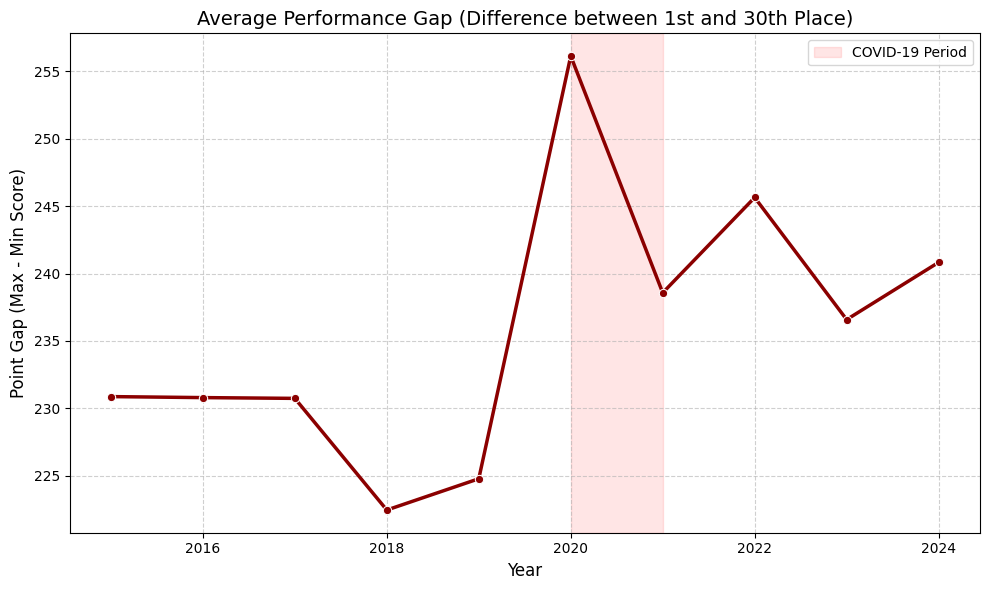

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Datensatz laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# 2. Daten auf die relevanten Jahre einschränken (z.B. ab 2015)
df_recent = df[df['jahr'] >= 2015].copy()

# 3. Funktion zur Berechnung des Abstands (Max - Min) der Top 30
def calculate_gap(group):
    # Wir sortieren die Scores und nehmen die besten 30
    top_30 = group.sort_values(ascending=False).head(30)
    # Wir berechnen den Gap nur, wenn die Liste auch 30 Einträge hat
    if len(top_30) < 30:
        return None 
    return top_30.max() - top_30.min()

# 4. Den Gap für jede Disziplin, jedes Geschlecht und jede Altersklasse pro Jahr berechnen
gap_stats = df_recent.groupby(['jahr', 'disziplin', 'geschlecht', 'altersklasse'])['iaaf_score'].apply(calculate_gap).reset_index()
gap_stats.columns = ['year', 'discipline', 'gender', 'age_class', 'gap']

# Leere Werte (Listen mit weniger als 30 Einträgen) entfernen
gap_stats = gap_stats.dropna(subset=['gap'])

# 5. Den durchschnittlichen Gap pro Jahr berechnen
yearly_gap = gap_stats.groupby('year')['gap'].mean().reset_index()

# 6. Plot erstellen
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_gap, x='year', y='gap', marker='o', color='darkred', linewidth=2.5)

# Corona-Phase hervorheben
plt.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Period')

# Beschriftungen auf Englisch
plt.title('Average Performance Gap (Difference between 1st and 30th Place)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Point Gap (Max - Min Score)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Plot anzeigen
plt.show()

In [10]:
import pandas as pd

# Daten laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# Nach "Mattis" suchen (Groß-/Kleinschreibung wird ignoriert)
# Wir filtern nach der Kategorie 'Lauf/Gehen' oder suchen einfach im ganzen Set
results = df[df['name'].str.contains('Mattis', case=False, na=False)]

# Nur die wichtigsten Spalten anzeigen
print(results[['jahr', 'name', 'disziplin', 'iaaf_score', 'altersklasse']])

        jahr               name       disziplin  iaaf_score altersklasse
13951   2015    Mattis Thoerner      Hochsprung         741           16
13985   2015    Mattis Thoerner  Stabhochsprung         569           16
14014   2015    Mattis Thoerner      Weitsprung         782           16
14158   2015    Mattis Thoerner       Speerwurf         706           16
17240   2006    Jan Mattis Kuhn          3000 m         836           20
...      ...                ...             ...         ...          ...
223022  2023     Mattis Thomsen      Dreisprung         758          U23
226165  2023  Mattis Gerntholtz           100 m         605           14
226369  2023  Mattis Gerntholtz      Hochsprung         621           14
226436  2023  Mattis Gerntholtz      Weitsprung         738           14
226625  2023      Mattis Orthen      Hammerwurf         224           14

[86 rows x 5 columns]


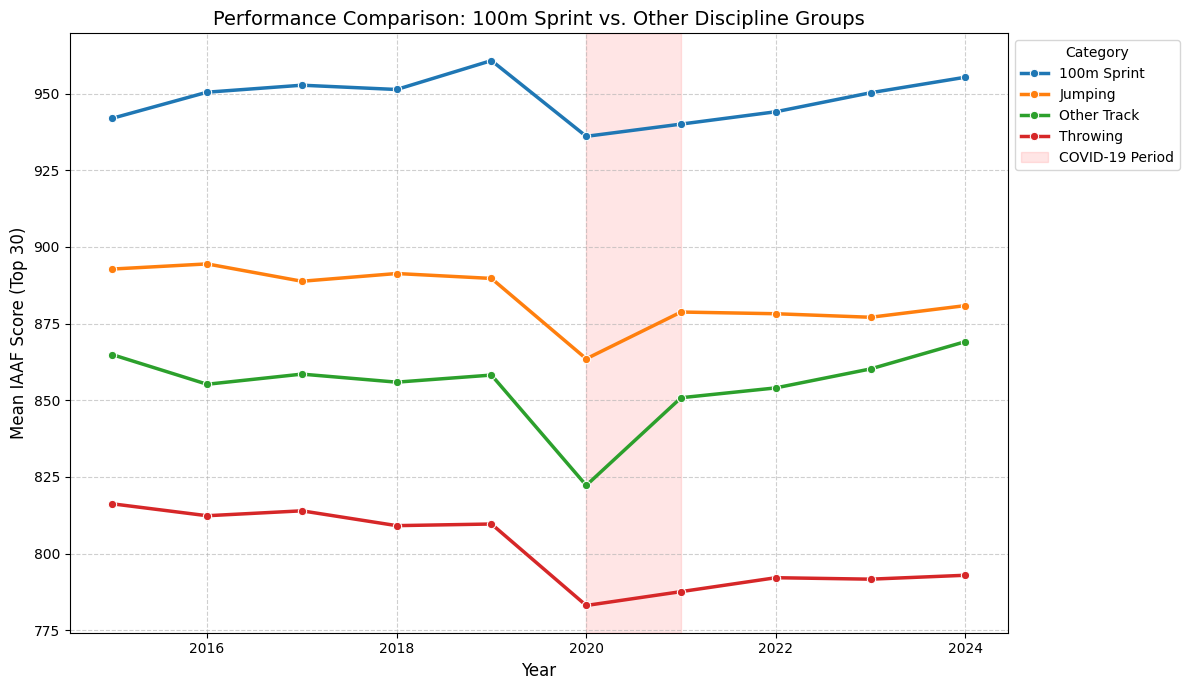

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv('Data_iaaf_scores_neu.csv', sep=';')

# 2. Neue Kategorisierung (100m separat)
def categorize_with_100m(d):
    d = str(d).lower()
    # 100m isolieren (aber nicht 100m Hürden)
    if '100 m' in d and 'huerden' not in d:
        return '100m Sprint'
    if any(x in d for x in ['sprung']):
        return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']):
        return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']):
        return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize_with_100m)

# 3. Top 30 Berechnung
df_recent = df[df['jahr'] >= 2015].copy()

# Hilfsfunktion für Mittelwert der Top 30
def get_top_30_mean(group):
    return group.nlargest(30).mean()

# Gruppieren
top_30_stats = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score'].apply(get_top_30_mean).reset_index()
final_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score'].mean().reset_index()

# 4. Plot erstellen
plt.figure(figsize=(12, 7))
sns.lineplot(data=final_stats, x='jahr', y='iaaf_score', hue='category', marker='o', linewidth=2.5)

plt.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Period')

plt.title('Performance Comparison: 100m Sprint vs. Other Discipline Groups', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean IAAF Score (Top 30)', fontsize=12)
plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('top_30_with_100m_separate.png')
plt.show()